Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path
import pingouin as pg

plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
standard_model_path = (
    Path.cwd().parent.parent / "results" / "standard_model_summary.csv"
)
standard_model_df = pd.read_csv(standard_model_path, low_memory=False)
standard_model_df = standard_model_df[standard_model_df.session == 2]

cardiac_believing_path = (
    Path.cwd().parent.parent / "results" / "cardiac_believing_summary.csv"
)
cardiac_believing_df = pd.read_csv(cardiac_believing_path, low_memory=False)
cardiac_believing_df = cardiac_believing_df[cardiac_believing_df.session == 2]

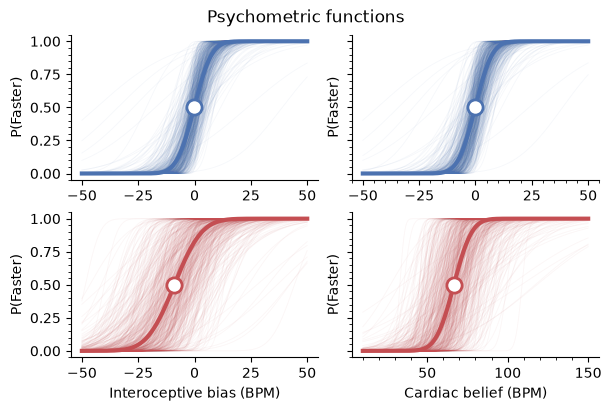

In [3]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(6, 4), sharey=True)

# Standard psychophysics --------------------
x_standard = np.linspace(-50, 50, 500)
for participant_id in standard_model_df.participant_id.to_list():
    extero_threshold = standard_model_df[
        standard_model_df.participant_id == participant_id
    ].extero_threshold.values[0]
    intero_threshold = standard_model_df[
        standard_model_df.participant_id == participant_id
    ].intero_threshold.values[0]
    intero_slope = standard_model_df[
        standard_model_df.participant_id == participant_id
    ].intero_slope.values[0]
    extero_slope = standard_model_df[
        standard_model_df.participant_id == participant_id
    ].extero_slope.values[0]

    axs[0, 0].plot(
        x_standard,
        (norm.cdf(x_standard, loc=extero_threshold, scale=extero_slope)),
        "-",
        alpha=0.05,
        linewidth=0.6,
        color="#4c72b0",
    )

    axs[1, 0].plot(
        x_standard,
        (norm.cdf(x_standard, loc=intero_threshold, scale=intero_slope)),
        "-",
        alpha=0.05,
        linewidth=0.6,
        color="#c44e52",
    )

axs[0, 0].plot(
    x_standard,
    (
        norm.cdf(
            x_standard,
            loc=standard_model_df.extero_threshold.mean(),
            scale=standard_model_df.extero_slope.mean(),
        )
    ),
    "-",
    color="#4c72b0",
    linewidth=3.0,
)
axs[0, 0].scatter(
    x=standard_model_df.extero_threshold.mean(),
    y=0.5,
    color="w",
    edgecolors="#4c72b0",
    zorder=10,
    s=120,
    linewidths=2,
)

axs[1, 0].plot(
    x_standard,
    (
        norm.cdf(
            x_standard,
            loc=standard_model_df.intero_threshold.mean(),
            scale=standard_model_df.intero_slope.mean(),
        )
    ),
    "-",
    color="#c44e52",
    linewidth=3.0,
)
axs[1, 0].scatter(
    x=standard_model_df.intero_threshold.mean(),
    y=0.5,
    color="w",
    edgecolors="#c44e52",
    zorder=10,
    s=120,
    linewidths=2,
)


# Cardiac believing --------------------
x_believing = np.linspace(10, 150, 500)
for participant_id in cardiac_believing_df.participant_id.to_list():
    extero_threshold = cardiac_believing_df[
        cardiac_believing_df.participant_id == participant_id
    ].extero_threshold.values[0]
    intero_mean = cardiac_believing_df[
        cardiac_believing_df.participant_id == participant_id
    ].intero_mean.values[0]
    intero_std = cardiac_believing_df[
        cardiac_believing_df.participant_id == participant_id
    ].intero_std.values[0]
    extero_slope = cardiac_believing_df[
        cardiac_believing_df.participant_id == participant_id
    ].extero_slope.values[0]

    axs[0, 1].plot(
        x_standard,
        (norm.cdf(x_standard, loc=extero_threshold, scale=extero_slope)),
        "-",
        alpha=0.05,
        linewidth=0.6,
        color="#4c72b0",
    )

    axs[1, 1].plot(
        x_believing,
        (norm.cdf(x_believing, loc=intero_mean, scale=intero_std)),
        "-",
        alpha=0.05,
        linewidth=0.6,
        color="#c44e52",
    )

axs[0, 1].plot(
    x_standard,
    (
        norm.cdf(
            x_standard,
            loc=cardiac_believing_df.extero_threshold.mean(),
            scale=cardiac_believing_df.extero_slope.mean(),
        )
    ),
    "-",
    color="#4c72b0",
    linewidth=3.0,
)
axs[0, 1].scatter(
    x=cardiac_believing_df.extero_threshold.mean(),
    y=0.5,
    color="w",
    edgecolors="#4c72b0",
    zorder=10,
    s=120,
    linewidths=2,
)

axs[1, 1].plot(
    x_believing,
    (
        norm.cdf(
            x_believing,
            loc=cardiac_believing_df.intero_mean.mean(),
            scale=cardiac_believing_df.intero_std.mean(),
        )
    ),
    "-",
    color="#c44e52",
    linewidth=3.0,
)
axs[1, 1].scatter(
    x=cardiac_believing_df.intero_mean.mean(),
    y=0.5,
    color="w",
    edgecolors="#c44e52",
    zorder=10,
    s=120,
    linewidths=2,
)

axs[0, 1].minorticks_on()
axs[1, 1].minorticks_on()

axs[0, 0].set(ylabel="P(Faster)")
axs[0, 1].set(ylabel="P(Faster)")
axs[1, 0].set(xlabel="Interoceptive bias (BPM)", ylabel="P(Faster)")
axs[1, 1].set(xlabel="Cardiac belief (BPM)", ylabel="P(Faster)")

sns.despine()

fig.suptitle("Psychometric functions")

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_2_psychometrics.svg")

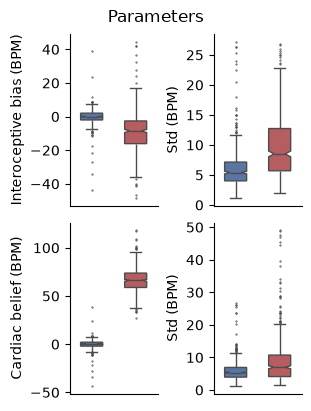

In [4]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(3, 4))

sns.boxplot(
    data=pd.melt(
        standard_model_df,
        id_vars=["participant_id"],
        value_vars=["extero_threshold", "intero_threshold"],
    ),
    x="variable",
    y="value",
    hue="variable",
    ax=axs[0, 0],
    palette=["#4c72b0", "#c44e52"],
    notch=True,
    fliersize=0.5,
    width=0.5,
)
axs[0, 0].set(ylabel="Interoceptive bias (BPM)", xlabel=None)
axs[0, 0].set_xticklabels([])
axs[0, 0].set_xticks([])

sns.boxplot(
    data=pd.melt(
        standard_model_df,
        id_vars=["participant_id"],
        value_vars=["extero_slope", "intero_slope"],
    ),
    x="variable",
    y="value",
    hue="variable",
    ax=axs[0, 1],
    palette=["#4c72b0", "#c44e52"],
    notch=True,
    fliersize=0.5,
    width=0.5,
)
axs[0, 1].set(ylabel="Std (BPM)", xlabel=None)
axs[0, 1].set_xticklabels([])
axs[0, 1].set_xticks([])

sns.boxplot(
    data=pd.melt(
        cardiac_believing_df,
        id_vars=["participant_id"],
        value_vars=["extero_threshold", "intero_mean"],
    ),
    x="variable",
    y="value",
    hue="variable",
    ax=axs[1, 0],
    palette=["#4c72b0", "#c44e52"],
    notch=True,
    fliersize=0.5,
    width=0.5,
)
axs[1, 0].set(ylabel="Cardiac belief (BPM)", xlabel=None)
axs[1, 0].set_xticklabels([])
axs[1, 0].set_xticks([])

sns.boxplot(
    data=pd.melt(
        cardiac_believing_df,
        id_vars=["participant_id"],
        value_vars=["extero_slope", "intero_std"],
    ),
    x="variable",
    y="value",
    hue="variable",
    ax=axs[1, 1],
    palette=["#4c72b0", "#c44e52"],
    notch=True,
    fliersize=0.5,
    width=0.5,
)
axs[1, 1].set(ylabel="Std (BPM)", xlabel=None)
axs[1, 1].set_xticklabels([])
axs[1, 1].set_xticks([])

fig.suptitle("Parameters")

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_2_boxplots.svg")

## Statistics
### Bayesian psychophysics

In [5]:
print(f"Mean extero threshold: {standard_model_df.extero_threshold.mean()}")
print(f"Mean intero threshold: {standard_model_df.intero_threshold.mean()}")
pg.ttest(
    x=standard_model_df.extero_threshold.to_numpy(),
    y=standard_model_df.intero_threshold.to_numpy(),
    paired=True,
)

Mean extero threshold: -0.16014798091434365
Mean intero threshold: -8.952434215493899


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,16.715484,517,two-sided,1.839644e-50,"[7.76, 9.83]",0.962636,1.0,9.514e+46


In [6]:
print(f"Mean extero slope: {standard_model_df.extero_slope.mean()}")
print(f"Mean intero slope: {standard_model_df.intero_slope.mean()}")
pg.ttest(
    x=standard_model_df.extero_slope.to_numpy(),
    y=standard_model_df.intero_slope.to_numpy(),
    paired=True,
)

Mean extero slope: 6.079714943402046
Mean intero slope: 9.559344851819166


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-13.450802,517,two-sided,1.408233e-35,"[-3.99, -2.97]",0.796554,1.0,1.652e+32


### Cardiac believing

In [7]:
print(f"Mean extero slope: {cardiac_believing_df.extero_slope.mean()}")
print(f"Mean intero slope: {cardiac_believing_df.intero_std.mean()}")
pg.ttest(
    x=cardiac_believing_df.extero_slope.to_numpy(),
    y=cardiac_believing_df.intero_std.to_numpy(),
    paired=True,
)

Mean extero slope: 5.938335883249288
Mean intero slope: 8.772601313654807


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-9.138525,517,two-sided,1.437681e-18,"[-3.44, -2.22]",0.503989,1.0,2.612e+15
